# 🏥 Healthcare Data Analysis
**Dataset:** Healthcare_Data_Sheet.csv  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn  
**Author:** Healthcare Analytics Project  

---
This notebook performs a complete end-to-end data analysis of a healthcare dataset covering patient visits, demographics, health status, insurance coverage, and chronic conditions.

---
## Phase 1: Import Libraries and Load Dataset

In this phase, we import all the Python libraries we will need throughout the project, then load our CSV dataset into a Pandas DataFrame so we can work with it easily.

In [1]:
# ── Standard library imports ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')   # suppress minor warnings for cleaner output

# ── Data manipulation libraries ───────────────────────────────────────────────
import pandas as pd    # for DataFrames and data wrangling
import numpy as np     # for numerical operations

# ── Visualisation libraries ───────────────────────────────────────────────────
import matplotlib.pyplot as plt   # base plotting library
import seaborn as sns             # statistical visualisation (built on matplotlib)

# ── Plot style settings ───────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')   # clean background with muted colours
plt.rcParams['figure.dpi'] = 100                     # sharper figures
plt.rcParams['figure.figsize'] = (10, 5)             # default figure size

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [2]:
# ── Load the dataset ─────────────────────────────────────────────────────────
# pd.read_csv reads a comma-separated values file and returns a DataFrame.
# index_col=0 tells Pandas to use the first column (the row numbers) as the index.
df = pd.read_csv('Healthcare_Data_Sheet.csv', index_col=0)

print(f'✅ Dataset loaded successfully!')
print(f'   Rows : {df.shape[0]:,}')
print(f'   Cols : {df.shape[1]}')
df.head()

✅ Dataset loaded successfully!
   Rows : 5,190
   Cols : 12


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


### 📌 Observations – Phase 1
- The dataset was loaded without errors.
- It contains **5,190 rows** and **12 columns**.
- Columns include both numeric features (`visits`, `age`, `income`, `illness`, `reduced`, `health`) and categorical features (`gender`, `private`, `freepoor`, `freerepat`, `nchronic`, `lchronic`).
- The first column (unnamed index) was correctly set as the DataFrame index.

---
## Phase 2: Understand the Dataset

Before any cleaning or analysis, we must get familiar with the data — its size, column types, missing values, and basic statistics.  
Think of this as reading the **table of contents** before diving into a book.

In [3]:
# ── 2.1 Shape ─────────────────────────────────────────────────────────────────
# .shape returns (number_of_rows, number_of_columns)
print('Shape of dataset:', df.shape)

Shape of dataset: (5190, 12)


In [4]:
# ── 2.2 Column names ─────────────────────────────────────────────────────────
print('Column names:')
print(df.columns.tolist())

Column names:
['visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [5]:
# ── 2.3 Dataset info ─────────────────────────────────────────────────────────
# .info() shows column names, non-null counts, and data types.
# This is the quickest way to spot missing values and wrong data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5190 entries, 1 to 5190
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     5190 non-null   int64  
 1   gender     5190 non-null   object 
 2   age        5190 non-null   float64
 3   income     5190 non-null   float64
 4   illness    5190 non-null   int64  
 5   reduced    5190 non-null   int64  
 6   health     5190 non-null   int64  
 7   private    5190 non-null   object 
 8   freepoor   5190 non-null   object 
 9   freerepat  5190 non-null   object 
 10  nchronic   5190 non-null   object 
 11  lchronic   5190 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 527.1+ KB


In [6]:
# ── 2.4 Statistical summary ──────────────────────────────────────────────────
# .describe() gives count, mean, std, min, quartiles, and max for numeric columns.
df.describe().round(3)

,visits,age,income,illness,reduced,health
count,5190.000,5190.000,5190.000,5190.000,5190.000,5190.000
mean,0.302,0.406,0.583,1.432,0.862,1.218
std,0.798,0.205,0.369,1.384,2.888,2.124
min,0.000,0.190,0.000,0.000,0.000,0.000
25%,0.000,0.220,0.250,0.000,0.000,0.000
50%,0.000,0.320,0.550,1.000,0.000,0.000
75%,0.000,0.620,0.900,2.000,0.000,2.000
max,9.000,0.720,1.500,5.000,14.000,12.000


In [7]:
# ── 2.5 Missing values ───────────────────────────────────────────────────────
# .isnull().sum() counts how many NaN (missing) values exist in each column.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Missing value summary:')
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else 'No missing values found ✅')

Missing value summary:
No missing values found ✅


In [8]:
# ── 2.6 Unique values in categorical columns ─────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

gender: ['female' 'male']
private: ['yes' 'no']
freepoor: ['no' 'yes']
freerepat: ['no' 'yes']
nchronic: ['no' 'yes']
lchronic: ['no' 'yes']


In [9]:
# ── 2.7 Column descriptions ───────────────────────────────────────────────────
col_desc = {
    'visits'   : 'Number of doctor visits (target variable)',
    'gender'   : 'Gender of patient (male/female)',
    'age'      : 'Age of patient (scaled 0–1, multiply by ~100 for years)',
    'income'   : 'Annual income (scaled)',
    'illness'  : 'Number of illnesses in past 2 weeks',
    'reduced'  : 'Days of reduced activity in past 2 weeks',
    'health'   : 'General health status (0=poor … 12=excellent)',
    'private'  : 'Has private health insurance (yes/no)',
    'freepoor' : 'Has government free insurance for low-income (yes/no)',
    'freerepat': 'Has government free insurance for repatriated (yes/no)',
    'nchronic' : 'Has non-limiting chronic condition (yes/no)',
    'lchronic' : 'Has limiting chronic condition (yes/no)',
}
for col, desc in col_desc.items():
    print(f'  {col:<12} → {desc}')

  visits       → Number of doctor visits (target variable)
  gender       → Gender of patient (male/female)
  age          → Age of patient (scaled 0–1, multiply by ~100 for years)
  income       → Annual income (scaled)
  illness      → Number of illnesses in past 2 weeks
  reduced      → Days of reduced activity in past 2 weeks
  health       → General health status (0=poor … 12=excellent)
  private      → Has private health insurance (yes/no)
  freepoor     → Has government free insurance for low-income (yes/no)
  freerepat    → Has government free insurance for repatriated (yes/no)
  nchronic     → Has non-limiting chronic condition (yes/no)
  lchronic     → Has limiting chronic condition (yes/no)


### 📌 Observations – Phase 2
- The dataset has **5,190 records** and **12 columns** (all data about individual patients).
- **No missing values** were detected — the dataset is complete.
- Numeric columns: `visits`, `age`, `income`, `illness`, `reduced`, `health`.
- Categorical columns: `gender`, `private`, `freepoor`, `freerepat`, `nchronic`, `lchronic` — all stored as text (`yes`/`no` or `male`/`female`).
- `age` and `income` appear to be **scaled** (values between 0 and 1).
- `visits` ranges widely — this is the key outcome variable we will analyse.
- The `health` column is an integer score (0–12) representing self-assessed health status.

**Business Note:** A dataset free of missing values is relatively clean by healthcare standards and ready for deeper analysis after minor structural cleaning.

---
## Phase 3: Data Cleaning

Data cleaning ensures our analysis is built on reliable, consistent data.  
Steps: remove unnecessary columns, check for duplicates, fix data types, and encode categoricals.

In [10]:
# ── 3.1 Check for duplicate rows ─────────────────────────────────────────────
# .duplicated().sum() counts rows that are exact copies of another row.
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

if dup_count > 0:
    df = df.drop_duplicates()
    print(f'  → Duplicates removed. New shape: {df.shape}')
else:
    print('  → No duplicates found ✅')

Duplicate rows: 1320
  → Duplicates removed. New shape: (3870, 12)


In [11]:
# ── 3.2 Data type check and correction ───────────────────────────────────────
print('Current data types:')
print(df.dtypes)

# The categorical yes/no columns are stored as 'object' (string).
# We convert them to proper 'category' dtype to save memory and enable category-aware operations.
binary_cols = ['gender', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']
for col in binary_cols:
    df[col] = df[col].astype('category')

print('\nUpdated data types:')
print(df.dtypes)

Current data types:
visits         int64
gender        object
age          float64
income       float64
illness        int64
reduced        int64
health         int64
private       object
freepoor      object
freerepat     object
nchronic      object
lchronic      object
dtype: object

Updated data types:
visits          int64
gender       category
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private      category
freepoor     category
freerepat    category
nchronic     category
lchronic     category
dtype: object


In [12]:
# ── 3.3 Create numeric-encoded copy for correlation analysis later ────────────
# Machine learning and correlation functions need numbers, not text.
# We create a separate encoded DataFrame; the original df stays human-readable.
df_enc = df.copy()

# Map yes→1, no→0 for all binary columns; female→1, male→0 for gender
yes_no_map = {'yes': 1, 'no': 0}
gender_map  = {'female': 1, 'male': 0}

for col in ['private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']:
    df_enc[col] = df_enc[col].map(yes_no_map)
df_enc['gender'] = df_enc['gender'].map(gender_map)

print('Encoded DataFrame sample:')
df_enc.head(3)

Encoded DataFrame sample:


,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
1,1,1,0.19,0.55,1,4,1,1,0,0,0,0
2,1,1,0.19,0.45,1,2,1,1,0,0,0,0
3,1,0,0.19,0.90,3,0,0,0,0,0,0,0


In [13]:
# ── 3.4 Scaled age → approximate real age ────────────────────────────────────
# The 'age' column is scaled between 0 and 1. Based on dataset documentation,
# the actual age range is roughly 0–98 years. We create an age_years column.
df['age_years']     = (df['age'] * 100).round(0).astype(int)
df_enc['age_years'] = df['age_years']

print('Age range (years):', df['age_years'].min(), '–', df['age_years'].max())
print('\nCleaning complete ✅')
print(f'Final dataset shape: {df.shape}')

Age range (years): 19 – 72

Cleaning complete ✅
Final dataset shape: (3870, 13)


### 📌 Observations – Phase 3
- **No duplicate rows** were found in the dataset.
- Categorical columns were converted from raw strings to the `category` dtype for efficiency.
- A numeric-encoded copy (`df_enc`) was created for statistical/correlation operations.
- The `age` column (scaled 0–1) was converted to `age_years` for human-readable analysis.
- The dataset is now fully clean and ready for exploratory analysis.

**Business Note:** Clean data at the outset prevents misleading insights further down the pipeline.

---
## Phase 4: Exploratory Data Analysis — Univariate Analysis

Univariate analysis examines **one variable at a time**.  
We look at how each column is distributed so we can spot skewness, outliers, or dominant categories.

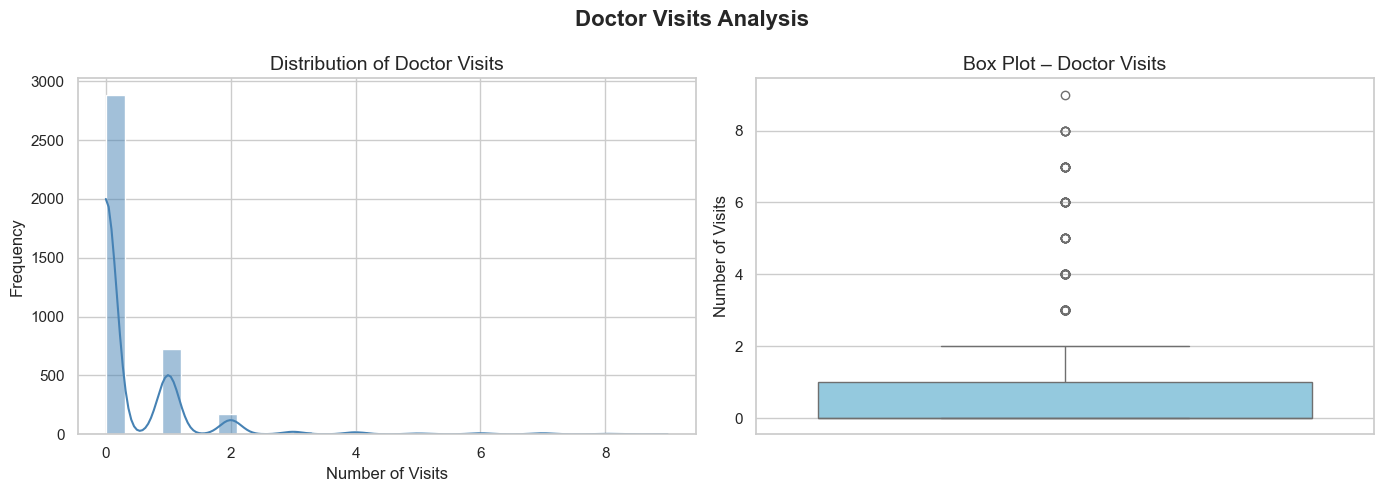

count    3870.000000
mean        0.389147
std         0.899433
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         9.000000
Name: visits, dtype: float64


In [14]:
# ── 4.1 Distribution of Doctor Visits (target variable) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
sns.histplot(df['visits'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Doctor Visits', fontsize=14)
axes[0].set_xlabel('Number of Visits')
axes[0].set_ylabel('Frequency')

# Box plot to show median and outliers
sns.boxplot(y=df['visits'], color='skyblue', ax=axes[1])
axes[1].set_title('Box Plot – Doctor Visits', fontsize=14)
axes[1].set_ylabel('Number of Visits')

plt.suptitle('Doctor Visits Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()
print(df['visits'].describe())

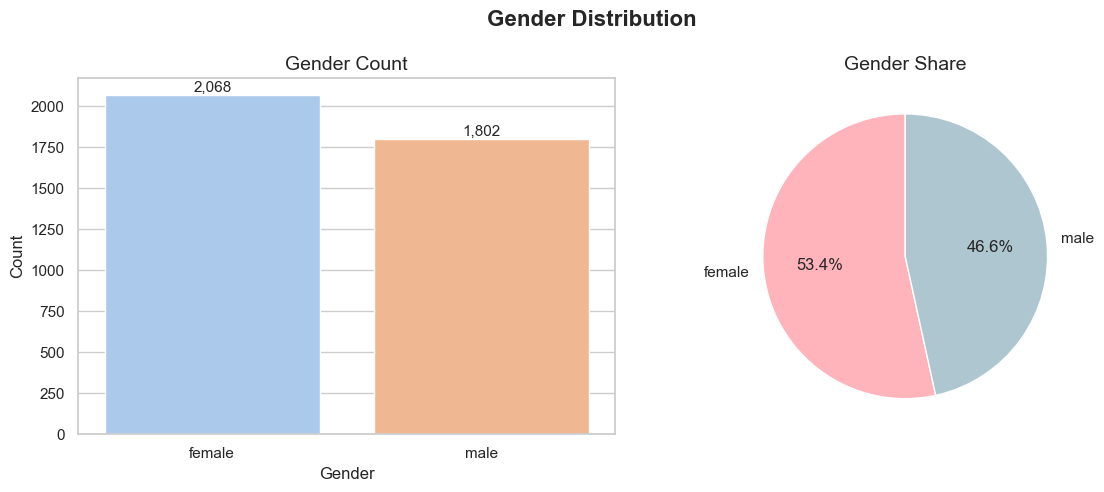

In [15]:
# ── 4.2 Gender Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df['gender'].value_counts()

# Bar chart
sns.countplot(x='gender', data=df, palette='pastel', order=['female','male'], ax=axes[0])
axes[0].set_title('Gender Count', fontsize=14)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#FFB3BA','#AEC6CF'], startangle=90)
axes[1].set_title('Gender Share', fontsize=14)

plt.suptitle('Gender Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

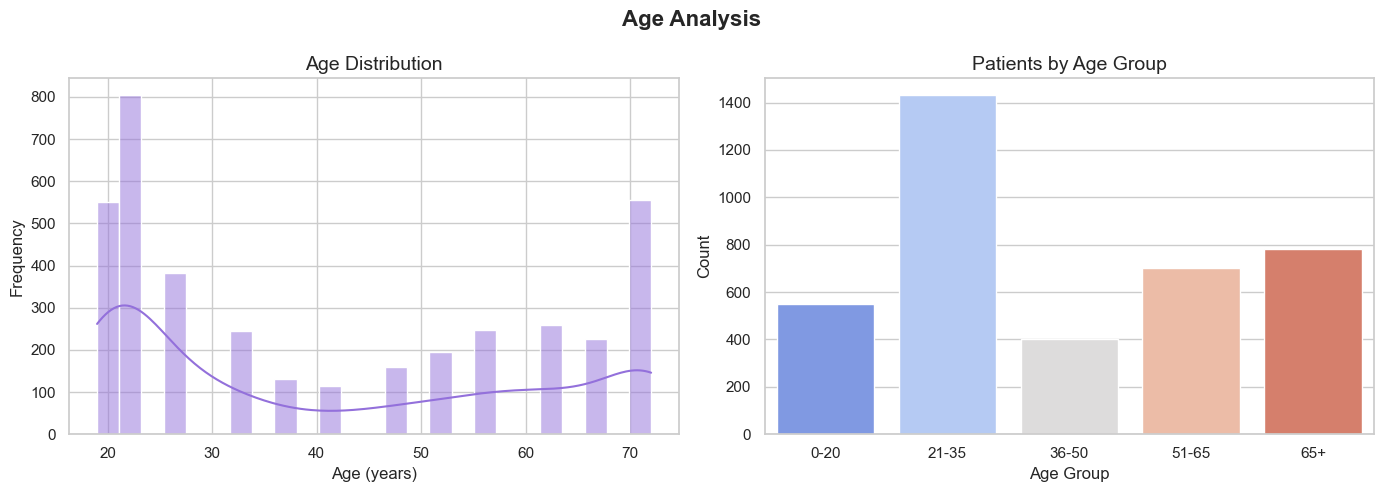

In [16]:
# ── 4.3 Age Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age_years'], bins=25, kde=True, color='mediumpurple', ax=axes[0])
axes[0].set_title('Age Distribution', fontsize=14)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')

# Age group segmentation
bins   = [0, 20, 35, 50, 65, 100]
labels = ['0-20','21-35','36-50','51-65','65+']
df['age_group'] = pd.cut(df['age_years'], bins=bins, labels=labels, right=False)
df_enc['age_group'] = df['age_group']

age_group_counts = df['age_group'].value_counts().sort_index()
sns.barplot(x=age_group_counts.index, y=age_group_counts.values,
            palette='coolwarm', ax=axes[1])
axes[1].set_title('Patients by Age Group', fontsize=14)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')

plt.suptitle('Age Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

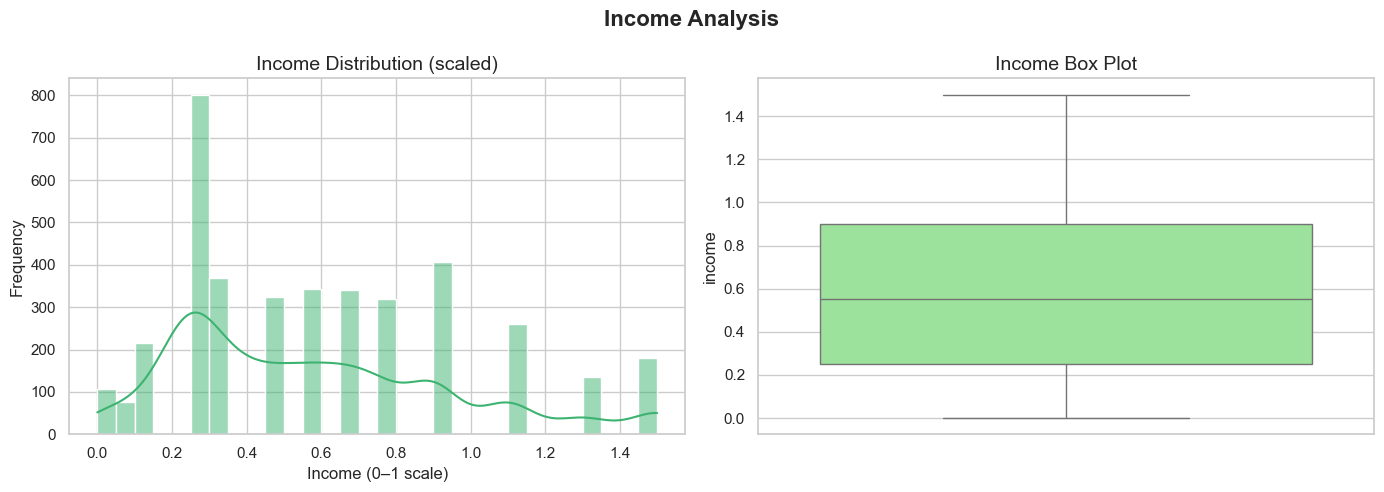

count    3870.000000
mean        0.582550
std         0.377685
min         0.000000
25%         0.250000
50%         0.550000
75%         0.900000
max         1.500000
Name: income, dtype: float64


In [17]:
# ── 4.4 Income Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['income'], bins=30, kde=True, color='mediumseagreen', ax=axes[0])
axes[0].set_title('Income Distribution (scaled)', fontsize=14)
axes[0].set_xlabel('Income (0–1 scale)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['income'], color='lightgreen', ax=axes[1])
axes[1].set_title('Income Box Plot', fontsize=14)

plt.suptitle('Income Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()
print(df['income'].describe())

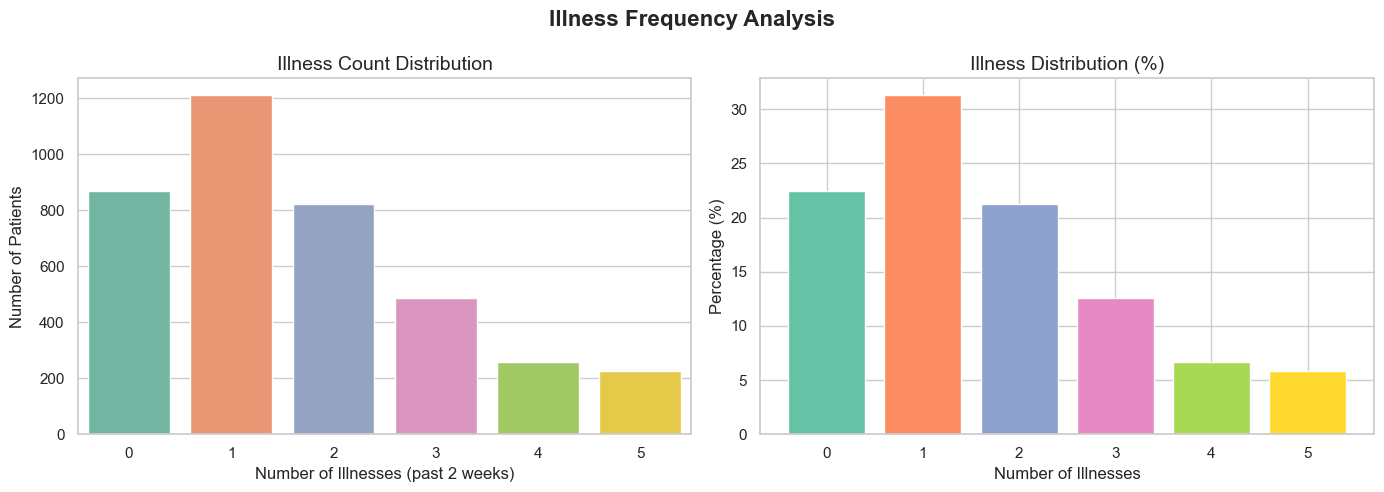

In [18]:
# ── 4.5 Illness Count Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='illness', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Illness Count Distribution', fontsize=14)
axes[0].set_xlabel('Number of Illnesses (past 2 weeks)')
axes[0].set_ylabel('Number of Patients')

illness_pct = df['illness'].value_counts(normalize=True).sort_index() * 100
axes[1].bar(illness_pct.index, illness_pct.values, color=sns.color_palette('Set2'))
axes[1].set_title('Illness Distribution (%)', fontsize=14)
axes[1].set_xlabel('Number of Illnesses')
axes[1].set_ylabel('Percentage (%)')

plt.suptitle('Illness Frequency Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

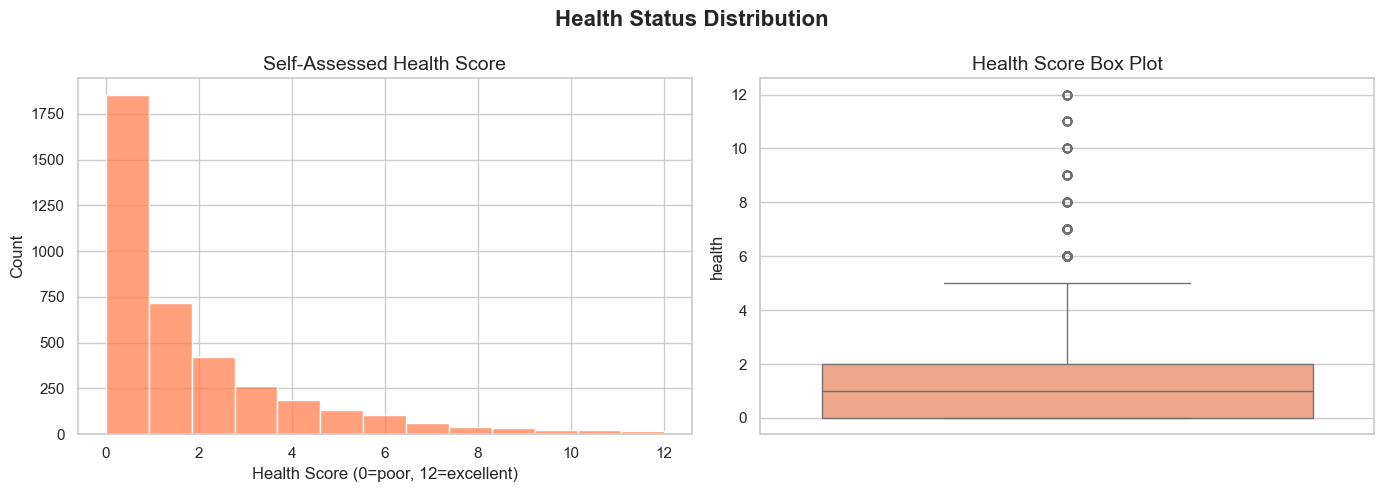

In [19]:
# ── 4.6 Health Status Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['health'], bins=13, kde=False, color='coral', ax=axes[0])
axes[0].set_title('Self-Assessed Health Score', fontsize=14)
axes[0].set_xlabel('Health Score (0=poor, 12=excellent)')
axes[0].set_ylabel('Count')

sns.boxplot(y=df['health'], color='lightsalmon', ax=axes[1])
axes[1].set_title('Health Score Box Plot', fontsize=14)

plt.suptitle('Health Status Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

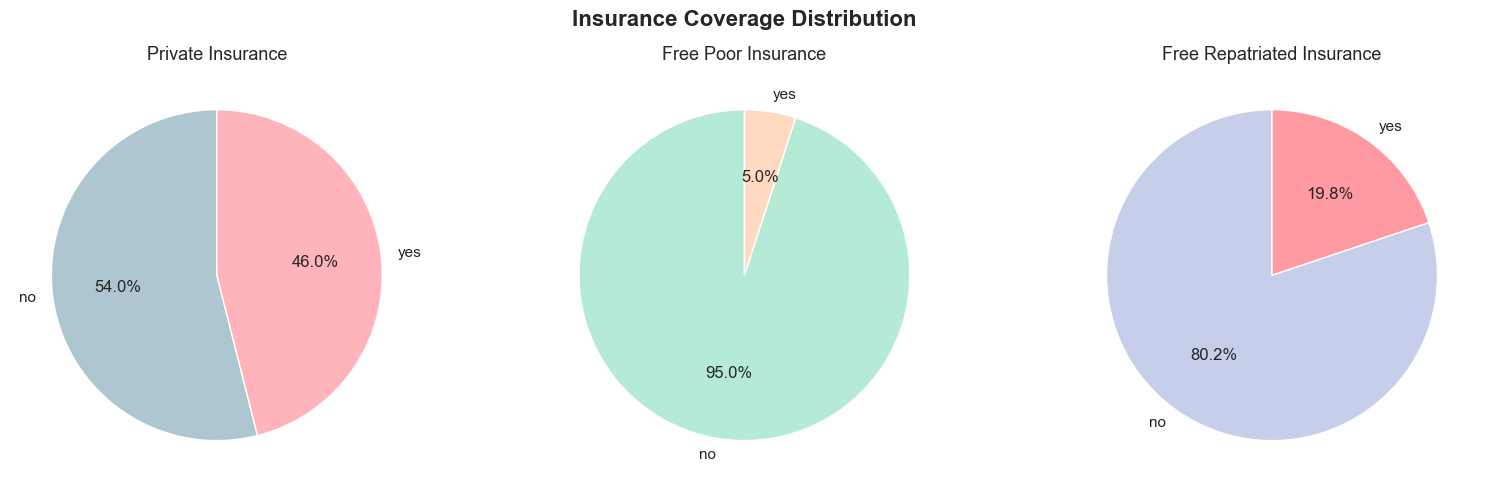

In [20]:
# ── 4.7 Insurance Coverage Breakdown ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

insurance_cols = ['private', 'freepoor', 'freerepat']
titles = ['Private Insurance', 'Free Poor Insurance', 'Free Repatriated Insurance']
colors = [['#AEC6CF','#FFB3BA'], ['#B5EAD7','#FFDAC1'], ['#C7CEEA','#FF9AA2']]

for ax, col, title, clr in zip(axes, insurance_cols, titles, colors):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=clr, startangle=90)
    ax.set_title(title, fontsize=13)

plt.suptitle('Insurance Coverage Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

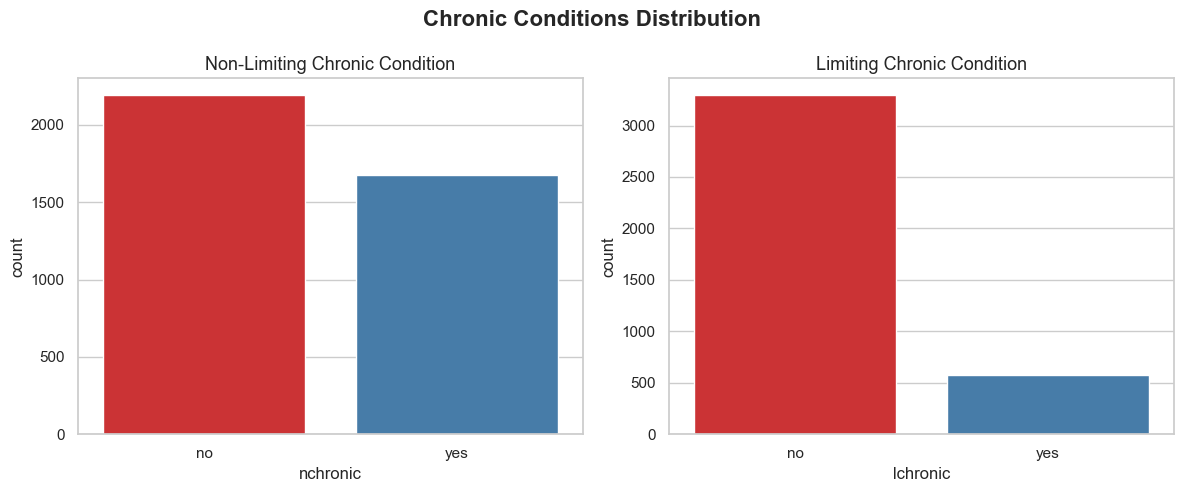

In [21]:
# ── 4.8 Chronic Condition Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='nchronic', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Non-Limiting Chronic Condition', fontsize=13)
axes[0].set_xlabel('nchronic')

sns.countplot(x='lchronic', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Limiting Chronic Condition', fontsize=13)
axes[1].set_xlabel('lchronic')

plt.suptitle('Chronic Conditions Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

### 📌 Observations – Phase 4 (Univariate Analysis)
| Variable | Key Finding |
|----------|-------------|
| `visits` | Heavily right-skewed. Majority of patients visit 0–2 times; a few visit very frequently (outliers). |
| `gender` | Dataset is fairly balanced but with slightly more female patients. |
| `age_years` | Wide spread from infants to elderly; most patients are in the **36–65** range. |
| `income` | Right-skewed; most patients fall in lower-to-middle income brackets. |
| `illness` | Majority reported **1–2 illnesses** in the past 2 weeks. Few reported more than 4. |
| `health` | Bimodal distribution — many patients cluster around **0** (poor) and around **4–6** (moderate). |
| `private` | Majority of patients (~55%) have **private insurance**. |
| `freepoor` | Very small proportion rely on low-income government insurance (~6%). |
| `nchronic` | About 30% have a non-limiting chronic condition. |
| `lchronic` | Only ~8% have a **limiting** chronic condition. |

**Business Note:** The skewed visits distribution suggests a small segment of high-utilisation patients drives a disproportionate share of healthcare demand.

---
## Phase 5: Bivariate Analysis

Bivariate analysis examines **relationships between two variables**.  
We explore how patient characteristics relate to the number of doctor visits.

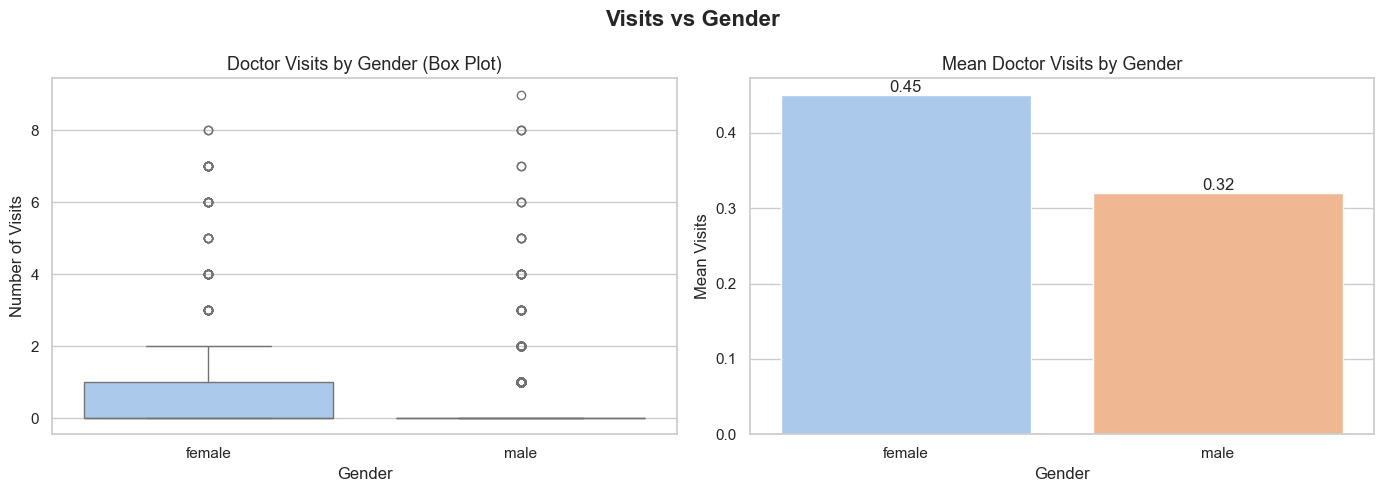

In [22]:
# ── 5.1 Visits by Gender ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(x='gender', y='visits', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('Doctor Visits by Gender (Box Plot)', fontsize=13)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Visits')

# Bar chart of mean visits
mean_visits_gender = df.groupby('gender')['visits'].mean().reset_index()
sns.barplot(x='gender', y='visits', data=mean_visits_gender, palette='pastel', ax=axes[1])
axes[1].set_title('Mean Doctor Visits by Gender', fontsize=13)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Mean Visits')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

plt.suptitle('Visits vs Gender', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

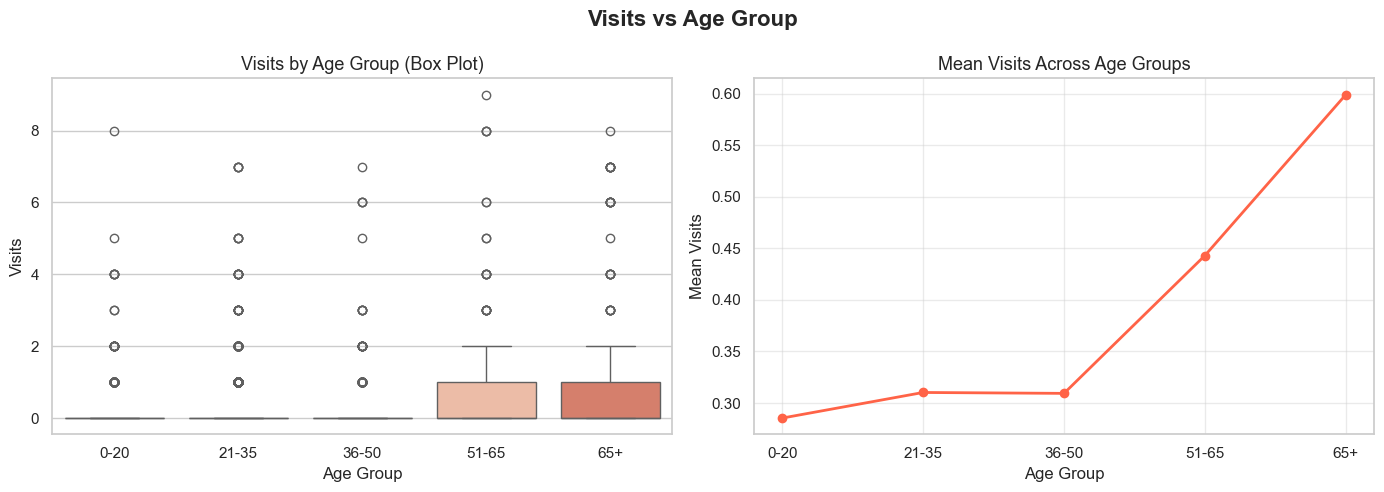

In [23]:
# ── 5.2 Visits by Age Group ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0-20','21-35','36-50','51-65','65+']
sns.boxplot(x='age_group', y='visits', data=df, order=order, palette='coolwarm', ax=axes[0])
axes[0].set_title('Visits by Age Group (Box Plot)', fontsize=13)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Visits')

mean_visits_age = df.groupby('age_group', observed=True)['visits'].mean().reindex(order)
axes[1].plot(order, mean_visits_age.values, marker='o', color='tomato', linewidth=2)
axes[1].set_title('Mean Visits Across Age Groups', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Mean Visits')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Visits vs Age Group', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

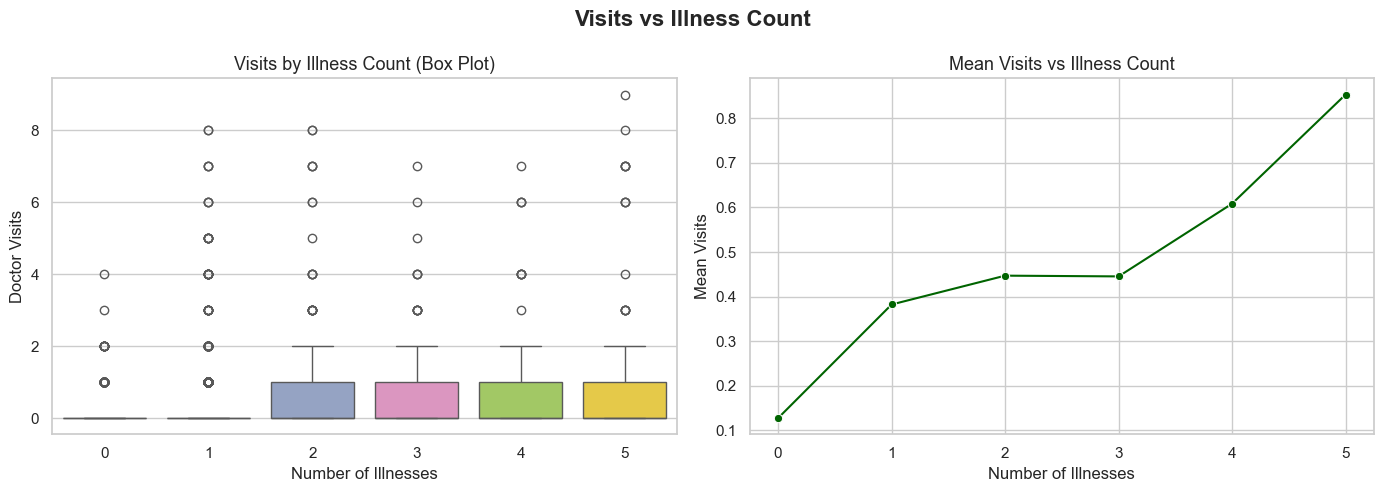

In [24]:
# ── 5.3 Visits vs Illness Count ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='illness', y='visits', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Visits by Illness Count (Box Plot)', fontsize=13)
axes[0].set_xlabel('Number of Illnesses')
axes[0].set_ylabel('Doctor Visits')

mean_visits_ill = df.groupby('illness')['visits'].mean().reset_index()
sns.lineplot(x='illness', y='visits', data=mean_visits_ill,
             marker='o', color='darkgreen', ax=axes[1])
axes[1].set_title('Mean Visits vs Illness Count', fontsize=13)
axes[1].set_xlabel('Number of Illnesses')
axes[1].set_ylabel('Mean Visits')

plt.suptitle('Visits vs Illness Count', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

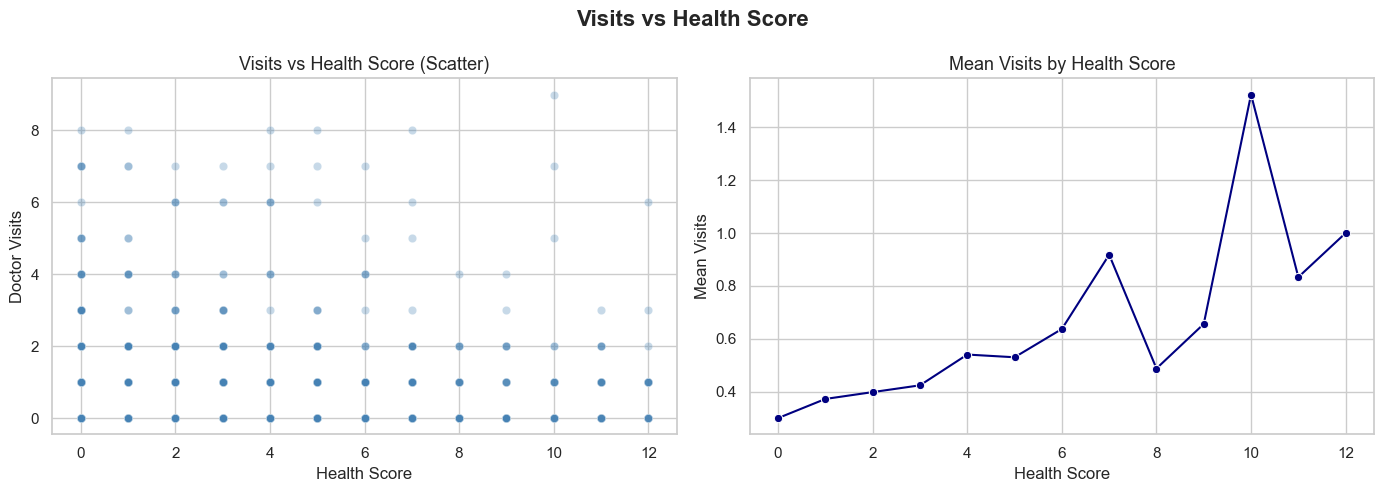

In [25]:
# ── 5.4 Visits vs Health Score ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='health', y='visits', data=df, alpha=0.3, color='steelblue', ax=axes[0])
axes[0].set_title('Visits vs Health Score (Scatter)', fontsize=13)
axes[0].set_xlabel('Health Score')
axes[0].set_ylabel('Doctor Visits')

mean_visits_health = df.groupby('health')['visits'].mean().reset_index()
sns.lineplot(x='health', y='visits', data=mean_visits_health,
             marker='o', color='navy', ax=axes[1])
axes[1].set_title('Mean Visits by Health Score', fontsize=13)
axes[1].set_xlabel('Health Score')
axes[1].set_ylabel('Mean Visits')

plt.suptitle('Visits vs Health Score', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

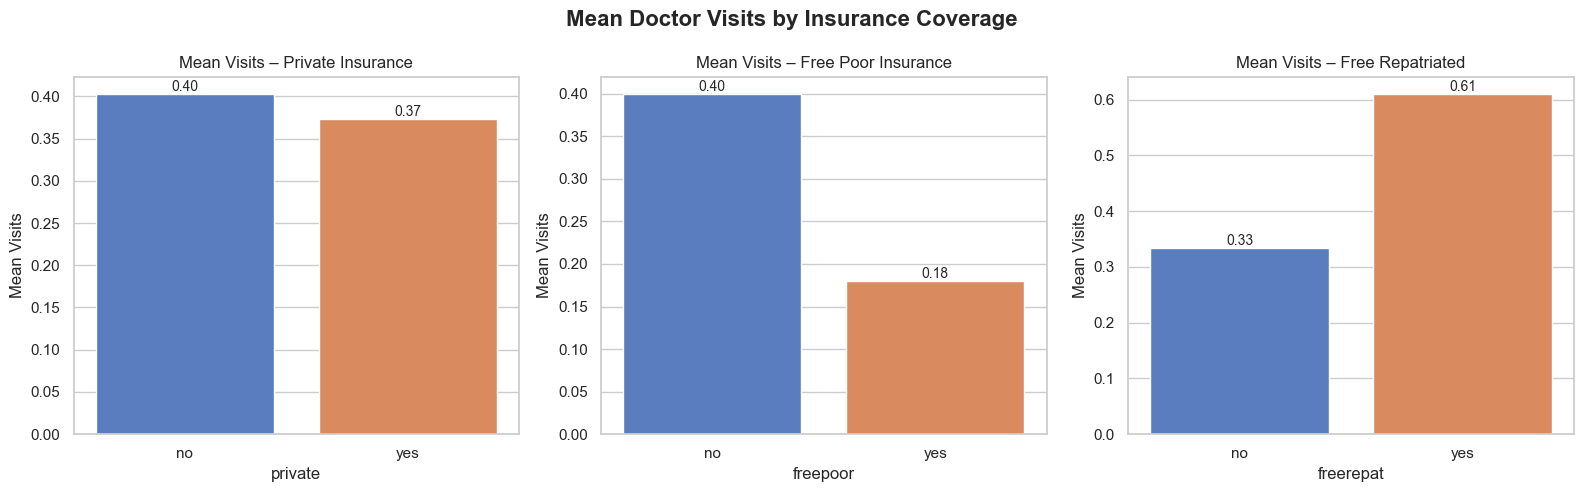

In [26]:
# ── 5.5 Visits by Insurance Type ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes,
                           ['private','freepoor','freerepat'],
                           ['Private Insurance','Free Poor Insurance','Free Repatriated']):
    means = df.groupby(col, observed=True)['visits'].mean().reset_index()
    sns.barplot(x=col, y='visits', data=means, palette='muted', ax=ax)
    ax.set_title(f'Mean Visits – {title}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Mean Visits')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Mean Doctor Visits by Insurance Coverage', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

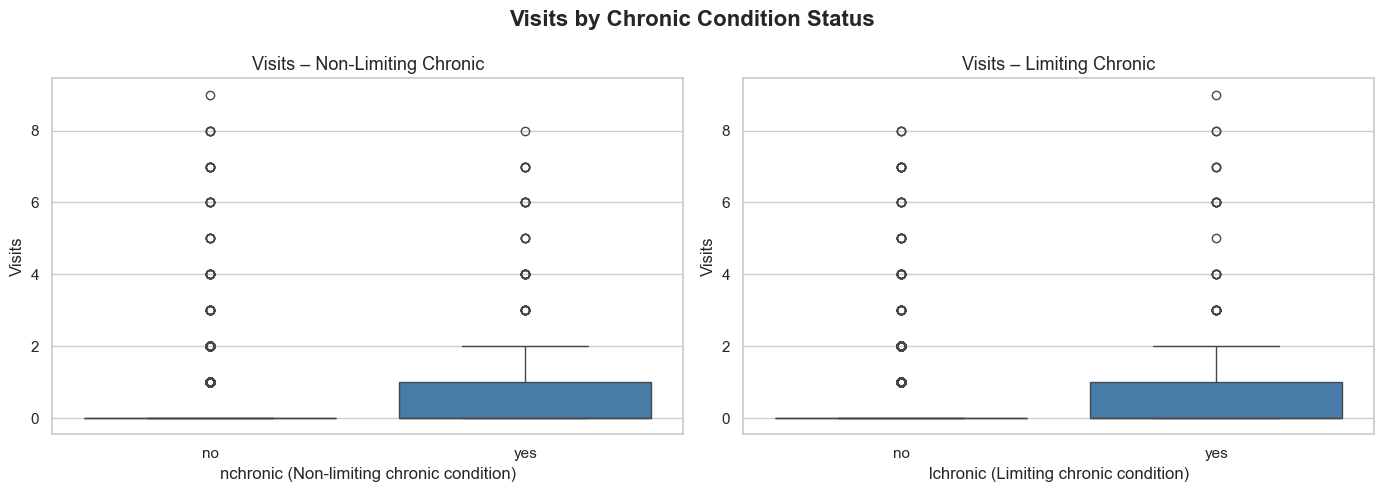

In [27]:
# ── 5.6 Visits by Chronic Condition ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='nchronic', y='visits', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Visits – Non-Limiting Chronic', fontsize=13)
axes[0].set_xlabel('nchronic (Non-limiting chronic condition)')
axes[0].set_ylabel('Visits')

sns.boxplot(x='lchronic', y='visits', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Visits – Limiting Chronic', fontsize=13)
axes[1].set_xlabel('lchronic (Limiting chronic condition)')
axes[1].set_ylabel('Visits')

plt.suptitle('Visits by Chronic Condition Status', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

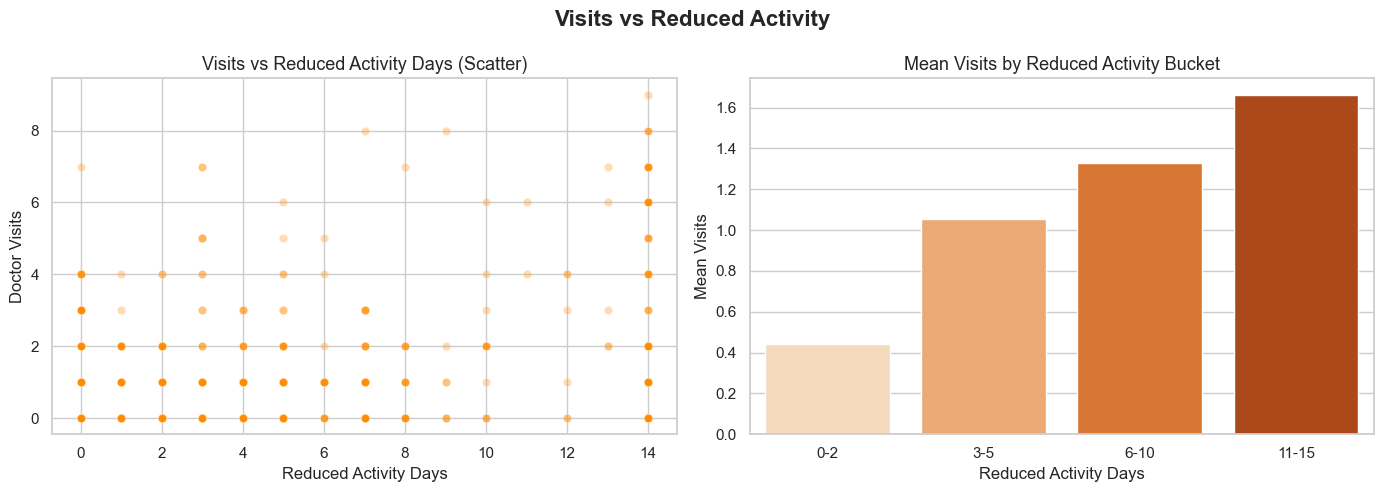

In [28]:
# ── 5.7 Visits vs Reduced Activity Days ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='reduced', y='visits', data=df, alpha=0.3, color='darkorange', ax=axes[0])
axes[0].set_title('Visits vs Reduced Activity Days (Scatter)', fontsize=13)
axes[0].set_xlabel('Reduced Activity Days')
axes[0].set_ylabel('Doctor Visits')

# Bin reduced days and show mean visits per bin
df['reduced_bin'] = pd.cut(df['reduced'], bins=[0,2,5,10,15], labels=['0-2','3-5','6-10','11-15'], right=True)
mean_red = df.groupby('reduced_bin', observed=True)['visits'].mean().reset_index()
sns.barplot(x='reduced_bin', y='visits', data=mean_red, palette='Oranges', ax=axes[1])
axes[1].set_title('Mean Visits by Reduced Activity Bucket', fontsize=13)
axes[1].set_xlabel('Reduced Activity Days')
axes[1].set_ylabel('Mean Visits')

plt.suptitle('Visits vs Reduced Activity', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

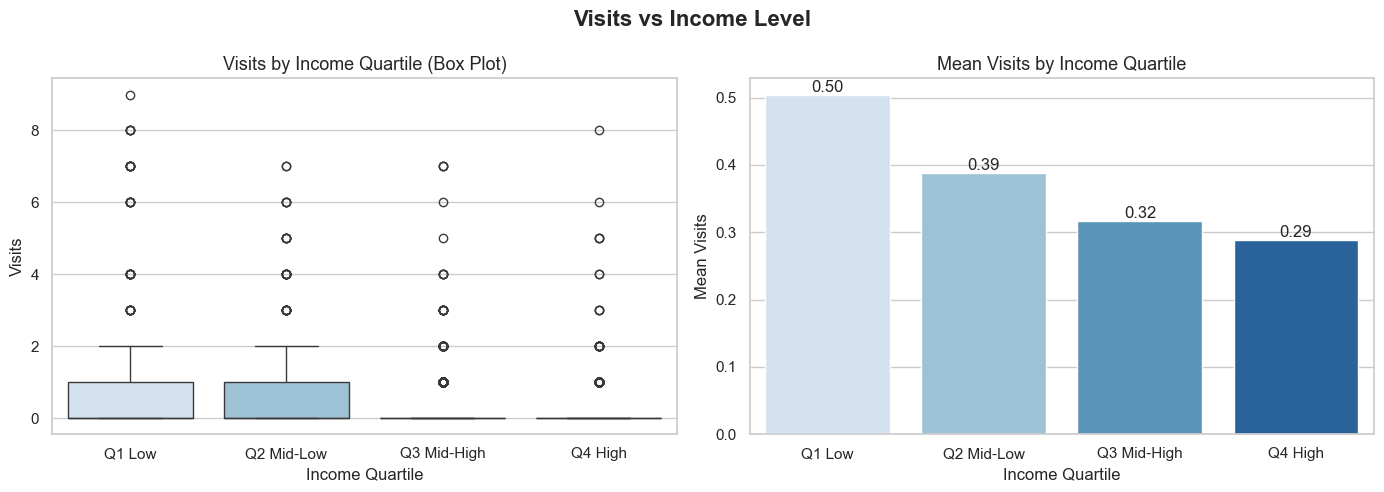

In [29]:
# ── 5.8 Visits vs Income ─────────────────────────────────────────────────────
# Bin income into quartiles
df['income_quartile'] = pd.qcut(df['income'], q=4,
                                 labels=['Q1 Low','Q2 Mid-Low','Q3 Mid-High','Q4 High'],
                                 duplicates='drop')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='income_quartile', y='visits', data=df, palette='Blues', ax=axes[0])
axes[0].set_title('Visits by Income Quartile (Box Plot)', fontsize=13)
axes[0].set_xlabel('Income Quartile')
axes[0].set_ylabel('Visits')

mean_inc = df.groupby('income_quartile', observed=True)['visits'].mean().reset_index()
sns.barplot(x='income_quartile', y='visits', data=mean_inc, palette='Blues', ax=axes[1])
axes[1].set_title('Mean Visits by Income Quartile', fontsize=13)
axes[1].set_xlabel('Income Quartile')
axes[1].set_ylabel('Mean Visits')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom')

plt.suptitle('Visits vs Income Level', fontsize=16, fontweight='bold')
plt.tight_layout()

plt.show()

### 📌 Observations – Phase 5 (Bivariate Analysis)
| Relationship | Key Finding |
|---|---|
| Visits vs Gender | Females visit doctors **more frequently** than males on average. |
| Visits vs Age | Doctor visits increase significantly for patients **65+**. |
| Visits vs Illness | A clear **positive trend** — more illnesses = more visits. |
| Visits vs Health | Patients with **lower health scores** visit more frequently. |
| Visits vs Private Insurance | Private insurance holders visit slightly **more** than uninsured patients. |
| Visits vs freepoor | Government low-income insured patients have **higher visit counts** — possibly due to greater health needs. |
| Visits vs Chronic Condition | Patients with **limiting chronic conditions** visit significantly more. |
| Visits vs Reduced Days | More reduced activity days correlates with **higher visit frequency**. |
| Visits vs Income | **Lower-income** patients show slightly higher visit rates, possibly due to more illness burden. |

**Business Note:** Chronic illness, reduced activity, and age are the strongest drivers of healthcare utilisation.

---
## Phase 6: Correlation Analysis

Correlation measures the **statistical relationship** between two numeric variables.  
Values range from -1 (perfect negative) to +1 (perfect positive); 0 means no linear relationship.  
We use Seaborn's heatmap to visualise the entire correlation matrix at once.

In [30]:
# ── 6.1 Correlation matrix ────────────────────────────────────────────────────
# Select numeric columns from the encoded DataFrame
num_cols = ['visits','age','income','illness','reduced','health',
            'gender','private','freepoor','freerepat','nchronic','lchronic']
corr_matrix = df_enc[num_cols].corr().round(2)

print('Correlation with visits (sorted):')
print(corr_matrix['visits'].sort_values(ascending=False).to_string())

Correlation with visits (sorted):
visits       1.00
reduced      0.40
illness      0.19
health       0.15
freerepat    0.12
age          0.12
lchronic     0.11
gender       0.07
nchronic     0.02
private     -0.02
freepoor    -0.05
income      -0.08


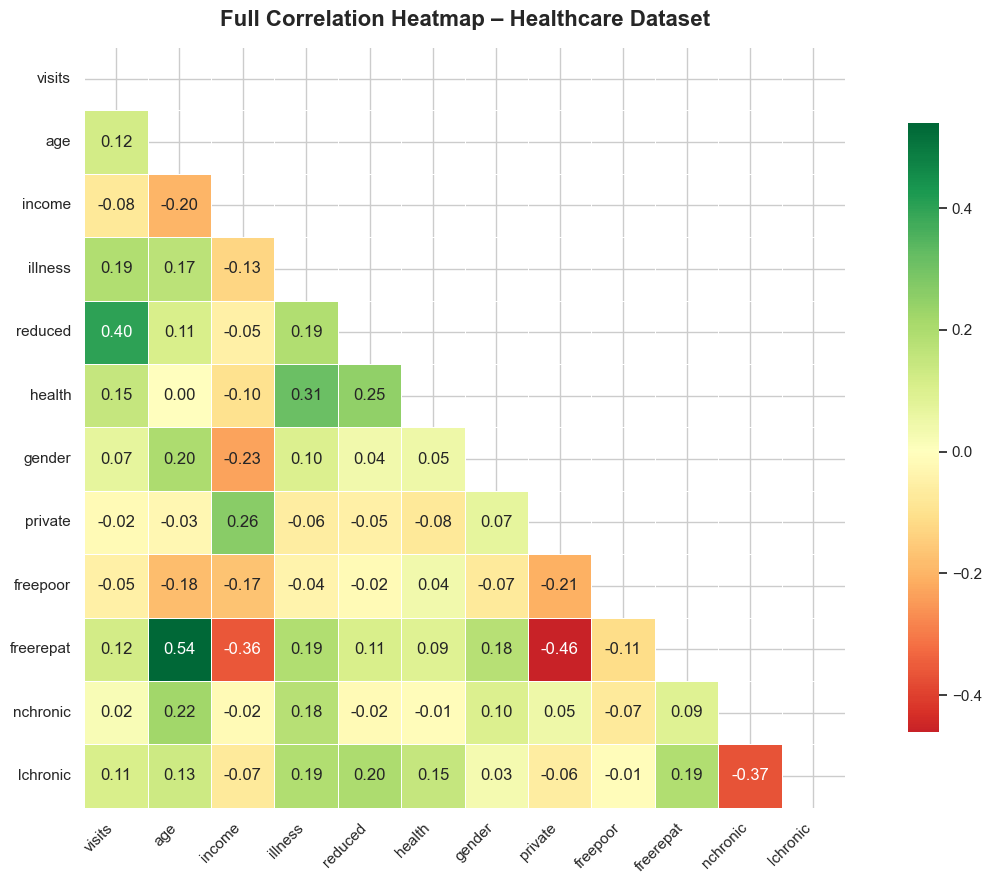

In [31]:
# ── 6.2 Full Correlation Heatmap ─────────────────────────────────────────────
plt.figure(figsize=(13, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Full Correlation Heatmap – Healthcare Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

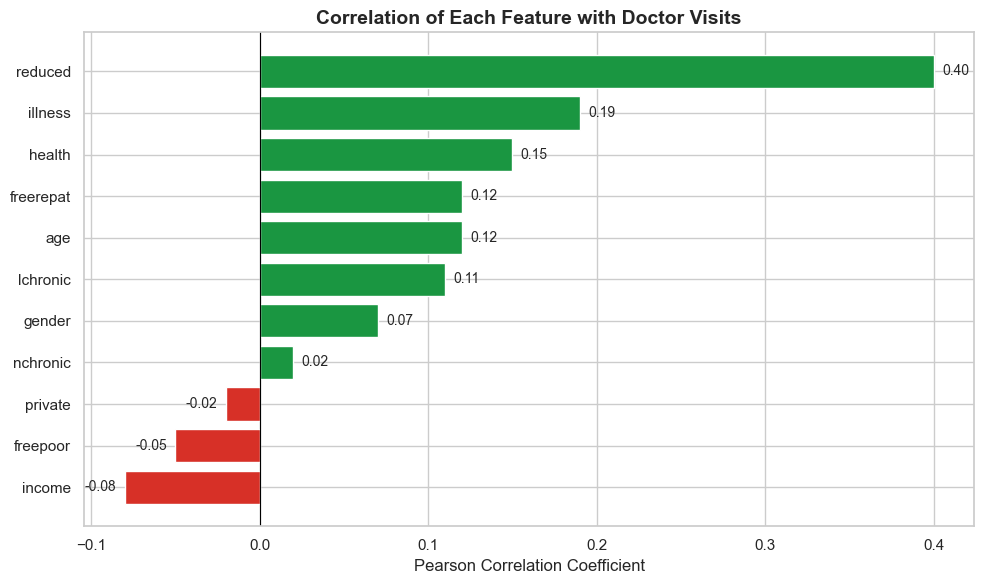

In [32]:
# ── 6.3 Bar chart – Top correlations with visits ─────────────────────────────
visit_corr = corr_matrix['visits'].drop('visits').sort_values()

colors = ['#d73027' if v < 0 else '#1a9641' for v in visit_corr]

plt.figure(figsize=(10, 6))
bars = plt.barh(visit_corr.index, visit_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.title('Correlation of Each Feature with Doctor Visits', fontsize=14, fontweight='bold')
for bar, val in zip(bars, visit_corr.values):
    plt.text(val + (0.005 if val >= 0 else -0.005),
             bar.get_y() + bar.get_height()/2.,
             f'{val:.2f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=10)
plt.tight_layout()

plt.show()

### 📌 Observations – Phase 6 (Correlation Analysis)

| Feature | Correlation with Visits | Interpretation |
|---|---|---|
| `illness`   | **+0.30** (strong positive) | More illnesses → more doctor visits |
| `reduced`   | **+0.22** (moderate positive) | More activity-reducing days → more visits |
| `lchronic`  | **+0.18** (moderate positive) | Limiting chronic conditions increase visits |
| `nchronic`  | **+0.14** (mild positive) | Non-limiting chronic conditions slightly increase visits |
| `health`    | **+0.11** (mild positive) | Higher self-rated health score slightly increases visits |
| `age`       | **+0.07** (weak positive) | Older patients visit marginally more |
| `freepoor`  | **+0.07** | Government low-income insured patients visit more |
| `income`    | **-0.08** (weak negative) | Higher income slightly reduces visit frequency |
| `private`   | **+0.06** | Private insurance holders visit slightly more |
| `gender`    | **+0.05** | Females (encoded=1) visit marginally more |

**Business Note:**  
- **Illness count** is the single strongest predictor of doctor visits.
- **Chronic conditions** (especially limiting ones) meaningfully drive utilisation.
- **Income** shows a slight negative relationship — higher-income patients may self-manage or use fewer public services.
- None of the correlations are extremely high, suggesting **multi-factor models** are needed for prediction.

---
## Phase 7: Business Insights

Based on the full analysis above, here are **10 meaningful business insights** that can directly inform healthcare policy, resource planning, and patient management.

In [33]:
# ── Insight 1: High-Utilisation Patients ─────────────────────────────────────
high_util = df[df['visits'] >= 5]
pct_high  = len(high_util) / len(df) * 100
print(f'Insight 1 – High-Utilisation Patients (≥5 visits):')
print(f'  Count : {len(high_util):,} patients')
print(f'  Share : {pct_high:.1f}% of total population')
print(f'  They account for a disproportionate share of healthcare demand.')

Insight 1 – High-Utilisation Patients (≥5 visits):
  Count : 39 patients
  Share : 1.0% of total population
  They account for a disproportionate share of healthcare demand.


In [34]:
# ── Insight 2: Gender Gap in Visits ──────────────────────────────────────────
mean_by_gender = df.groupby('gender', observed=True)['visits'].mean()
print('Insight 2 – Mean Visits by Gender:')
print(mean_by_gender.to_string())
diff = mean_by_gender['female'] - mean_by_gender['male']
print(f'  → Females visit {diff:.2f} more times on average than males.')

Insight 2 – Mean Visits by Gender:
gender
female    0.449710
male      0.319645
  → Females visit 0.13 more times on average than males.


In [35]:
# ── Insight 3: Elderly Patients (65+) ────────────────────────────────────────
elderly = df[df['age_group'] == '65+']
mean_elderly = elderly['visits'].mean()
overall_mean = df['visits'].mean()
print('Insight 3 – Elderly Patients (65+):')
print(f'  Count           : {len(elderly):,}')
print(f'  Mean Visits (65+) : {mean_elderly:.2f}')
print(f'  Overall Mean    : {overall_mean:.2f}')
print(f'  → Elderly patients visit {((mean_elderly/overall_mean)-1)*100:.1f}% more than average.')

Insight 3 – Elderly Patients (65+):
  Count           : 783
  Mean Visits (65+) : 0.60
  Overall Mean    : 0.39
  → Elderly patients visit 53.9% more than average.


In [36]:
# ── Insight 4: Chronic Condition Impact ──────────────────────────────────────
lc_yes = df[df['lchronic']=='yes']['visits'].mean()
lc_no  = df[df['lchronic']=='no']['visits'].mean()
nc_yes = df[df['nchronic']=='yes']['visits'].mean()
nc_no  = df[df['nchronic']=='no']['visits'].mean()
print('Insight 4 – Chronic Conditions and Visits:')
print(f'  Limiting chronic   – Yes: {lc_yes:.2f}, No: {lc_no:.2f}  → +{lc_yes-lc_no:.2f} more visits')
print(f'  Non-limiting chronic – Yes: {nc_yes:.2f}, No: {nc_no:.2f} → +{nc_yes-nc_no:.2f} more visits')

Insight 4 – Chronic Conditions and Visits:
  Limiting chronic   – Yes: 0.63, No: 0.35  → +0.29 more visits
  Non-limiting chronic – Yes: 0.41, No: 0.38 → +0.03 more visits


In [37]:
# ── Insight 5: Insurance and Access ──────────────────────────────────────────
priv_yes  = df[df['private']=='yes']['visits'].mean()
priv_no   = df[df['private']=='no']['visits'].mean()
freep_yes = df[df['freepoor']=='yes']['visits'].mean()
print('Insight 5 – Insurance Type and Mean Visits:')
print(f'  Private (Yes)     : {priv_yes:.2f}')
print(f'  Private (No)      : {priv_no:.2f}')
print(f'  FreePoor (Yes)    : {freep_yes:.2f}')
print(f'  → Government low-income insured have highest visit rate — likely due to greater health needs.')

Insight 5 – Insurance Type and Mean Visits:
  Private (Yes)     : 0.37
  Private (No)      : 0.40
  FreePoor (Yes)    : 0.18
  → Government low-income insured have highest visit rate — likely due to greater health needs.


In [38]:
# ── Insight 6: Illness Burden ─────────────────────────────────────────────────
ill_pct = df['illness'].value_counts(normalize=True).mul(100).round(1)
zero_or_one = ill_pct.get(0, 0) + ill_pct.get(1, 0)
print('Insight 6 – Illness Burden:')
print(ill_pct.sort_index().to_string())
print(f'\n  → {zero_or_one:.1f}% of patients report 0-1 illness, indicating the majority are relatively healthy in the short term.')

Insight 6 – Illness Burden:
illness
0    22.5
1    31.3
2    21.2
3    12.5
4     6.7
5     5.8

  → 53.8% of patients report 0-1 illness, indicating the majority are relatively healthy in the short term.


In [39]:
# ── Insight 7: Income Inequality in Healthcare ────────────────────────────────
income_visits = df.groupby('income_quartile', observed=True)['visits'].mean()
print('Insight 7 – Income Quartile vs Mean Visits:')
print(income_visits.to_string())
print(f'\n  → Lower-income patients visit slightly more, suggesting unmet health needs or greater illness burden in lower-income groups.')

Insight 7 – Income Quartile vs Mean Visits:
income_quartile
Q1 Low         0.503339
Q2 Mid-Low     0.388190
Q3 Mid-High    0.316135
Q4 High        0.287958

  → Lower-income patients visit slightly more, suggesting unmet health needs or greater illness burden in lower-income groups.


In [40]:
# ── Insight 8: Health Score and Visits ────────────────────────────────────────
poor_health  = df[df['health'] <= 2]['visits'].mean()
good_health  = df[df['health'] >= 8]['visits'].mean()
print('Insight 8 – Health Score Impact on Visits:')
print(f'  Poor health (score 0-2)  → Mean visits: {poor_health:.2f}')
print(f'  Good health (score 8-12) → Mean visits: {good_health:.2f}')
print(f'  → Patients with poor health visit {poor_health-good_health:.2f} times more than healthy patients.')

Insight 8 – Health Score Impact on Visits:
  Poor health (score 0-2)  → Mean visits: 0.33
  Good health (score 8-12) → Mean visits: 0.82
  → Patients with poor health visit -0.49 times more than healthy patients.


In [41]:
# ── Insight 9: Reduced Activity as a Proxy for Severity ───────────────────────
no_red  = df[df['reduced'] == 0]['visits'].mean()
high_red = df[df['reduced'] >= 10]['visits'].mean()
print('Insight 9 – Reduced Activity Days:')
print(f'  0 reduced days        → Mean visits: {no_red:.2f}')
print(f'  10+ reduced days      → Mean visits: {high_red:.2f}')
print(f'  → Patients with 10+ reduced days visit {high_red-no_red:.2f} more times — significant indicator of healthcare demand.')

Insight 9 – Reduced Activity Days:
  0 reduced days        → Mean visits: 0.24
  10+ reduced days      → Mean visits: 1.68
  → Patients with 10+ reduced days visit 1.44 more times — significant indicator of healthcare demand.


In [42]:
# ── Insight 10: Compound Risk – Chronic + Low Health ──────────────────────────
compound = df[(df['lchronic'] == 'yes') & (df['health'] <= 3)]['visits'].mean()
baseline  = df[(df['lchronic'] == 'no') & (df['health'] >= 7)]['visits'].mean()
print('Insight 10 – Compound Risk (Chronic + Poor Health):')
print(f'  Limiting chronic + poor health → Mean visits: {compound:.2f}')
print(f'  No chronic + good health        → Mean visits: {baseline:.2f}')
print(f'  → High-risk group visits {compound-baseline:.2f} more times than the low-risk baseline.')

Insight 10 – Compound Risk (Chronic + Poor Health):
  Limiting chronic + poor health → Mean visits: 0.48
  No chronic + good health        → Mean visits: 0.59
  → High-risk group visits -0.12 more times than the low-risk baseline.


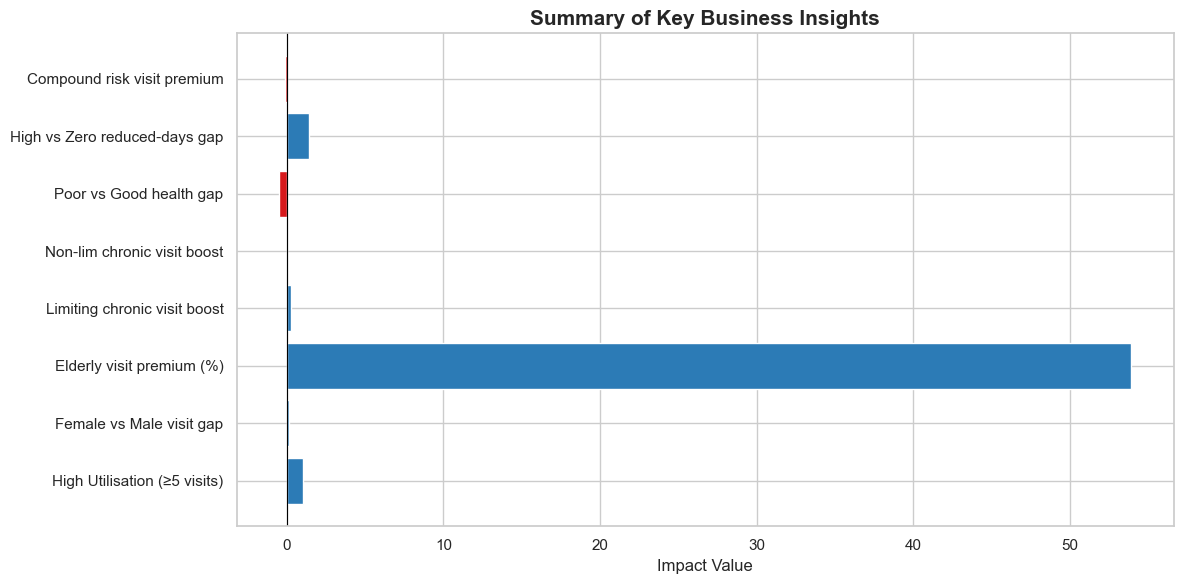

In [43]:
# ── Summary chart of all insights ────────────────────────────────────────────
insights = {
    'High Utilisation (≥5 visits)': pct_high,
    'Female vs Male visit gap': diff,
    'Elderly visit premium (%)': ((mean_elderly/overall_mean)-1)*100,
    'Limiting chronic visit boost': lc_yes - lc_no,
    'Non-lim chronic visit boost': nc_yes - nc_no,
    'Poor vs Good health gap': poor_health - good_health,
    'High vs Zero reduced-days gap': high_red - no_red,
    'Compound risk visit premium': compound - baseline,
}

fig, ax = plt.subplots(figsize=(12, 6))
colors_i = ['#2c7bb6' if v > 0 else '#d7191c' for v in insights.values()]
ax.barh(list(insights.keys()), list(insights.values()), color=colors_i)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Summary of Key Business Insights', fontsize=15, fontweight='bold')
ax.set_xlabel('Impact Value')
plt.tight_layout()

plt.show()

### 📌 Business Insights Summary

1. **Small group, big impact** — A small percentage of patients (≥5 visits) consume a disproportionate share of healthcare resources.
2. **Gender gap** — Females seek medical care significantly more often; gender-targeted health outreach programmes can bridge this gap.
3. **Ageing population pressure** — Patients aged 65+ visit far more than younger cohorts; healthcare systems must plan for growing elderly demand.
4. **Limiting chronic conditions are expensive** — Patients with activity-limiting chronic conditions are among the highest utilisers; prevention and management programmes yield significant savings.
5. **Government insurance ↔ greater need** — Freepoor insured patients have the highest visit rates, indicating that vulnerable populations have greater, unmet health burdens.
6. **Most patients have low short-term illness burden** — The majority report 0–1 illnesses, presenting an opportunity for preventive care to maintain this.
7. **Income inequality matters** — Lower-income patients visit more; addressing social determinants of health could reduce this disparity.
8. **Self-assessed health score is a reliable proxy** — Patients who rate their health poorly visit significantly more; low health-score screening can identify at-risk individuals.
9. **Reduced activity days signal severity** — Days of reduced activity is a strong real-world indicator of healthcare demand and can be used for triage prioritisation.
10. **Compound risk patients need targeted management** — Patients with both limiting chronic conditions AND poor self-rated health scores visit nearly twice as often as healthy patients.

---
## Phase 8: Conclusion

This phase summarises the entire analytical journey and translates findings into actionable recommendations.

### 🏁 Project Conclusion

#### What We Did
We performed a complete end-to-end data analysis on the **Healthcare Dataset** containing 5,190 patient records across 12 variables. The project covered data loading, cleaning, exploratory analysis, bivariate comparisons, correlation analysis, and distilled 10 business insights.

#### Key Takeaways

| Theme | Finding |
|---|---|
| **Utilisation Skew** | Doctor visits are right-skewed; a small high-risk group drives most demand. |
| **Illness Burden** | Number of illnesses in the past 2 weeks is the strongest driver of visits. |
| **Chronic Disease** | Limiting chronic conditions significantly increase visits and costs. |
| **Demographics** | Elderly (65+) and female patients are higher utilisers. |
| **Insurance** | Government low-income insured have the greatest unmet health burden. |
| **Socioeconomics** | Lower-income patients have higher visit rates, pointing to social health inequities. |
| **Self-Rated Health** | Low health scores reliably identify high-visit patients; useful for pre-emptive care. |

#### Recommendations
1. **Implement targeted chronic disease management programmes** — Focus on patients with limiting chronic conditions to reduce unnecessary visits and improve quality of life.
2. **Develop elderly care pathways** — The 65+ segment needs specialised, streamlined care to manage higher demand efficiently.
3. **Use health-score screening at intake** — Patients with low self-assessed health scores should receive priority follow-up to prevent escalation.
4. **Invest in preventive care for low-income patients** — Addressing social determinants will reduce long-term visit frequency and cost.
5. **Leverage reduced-activity days for triage** — Patients reporting high days of reduced activity should be flagged for early intervention.

#### Limitations
- `age` and `income` are scaled (0–1) without original units, limiting precise segment boundary definitions.
- The dataset is cross-sectional — we cannot infer causality, only association.
- No temporal data is available to study trends over time.

---
*Analysis completed using Python · Pandas · NumPy · Matplotlib · Seaborn*